In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv('/content/Global_Pollution_Analysis.csv')

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [4]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [5]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
df['Calculated_Energy_Per_Capita'] = (
    df['Energy_Consumption_Per_Capita (in MWh)'] /
    df['Population (in millions)']
)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita
0,77,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.297489
1,147,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.038106
2,136,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.105648
3,38,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.011504
4,46,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.068840


In [8]:
df['Yearly_Pollution_Trend'] = (
    df.groupby('Year')['Air_Pollution_Index']
    .transform('mean')
)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita,Yearly_Pollution_Trend
0,77,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.297489,179.756000
1,147,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.038106,137.964444
2,136,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.105648,163.471000
3,38,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.011504,244.112000
4,46,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.068840,194.782857


In [9]:
scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita,Yearly_Pollution_Trend
0,-0.232434,-0.753796,1.376167,0.193880,-0.619764,1.543328,-0.697051,-1.356325,1.079423,0.874923,0.561742,-1.093143,-0.737646,0.127192,-0.039399
1,1.173213,-1.449340,-1.403578,-1.153098,1.028744,0.124915,1.618760,-1.284276,0.700701,0.600289,-0.756197,0.580978,-0.023527,-0.336747,-1.929896
2,0.952326,1.158950,-1.330788,-0.668076,1.142400,0.123888,1.560644,1.718910,-1.493780,-0.395504,0.667825,0.355836,1.156054,-0.215940,-0.776072
3,-1.015580,1.506722,1.494394,-1.009403,0.431675,0.809131,-0.785350,-1.106232,-0.716061,-1.064327,-1.556310,-0.642506,-0.693157,-0.384327,2.871831
4,-0.854934,-0.232138,-0.021926,0.262567,1.138106,0.882681,-1.499375,-0.689181,0.502825,1.024815,0.612087,1.448956,0.312447,-0.281775,0.640361


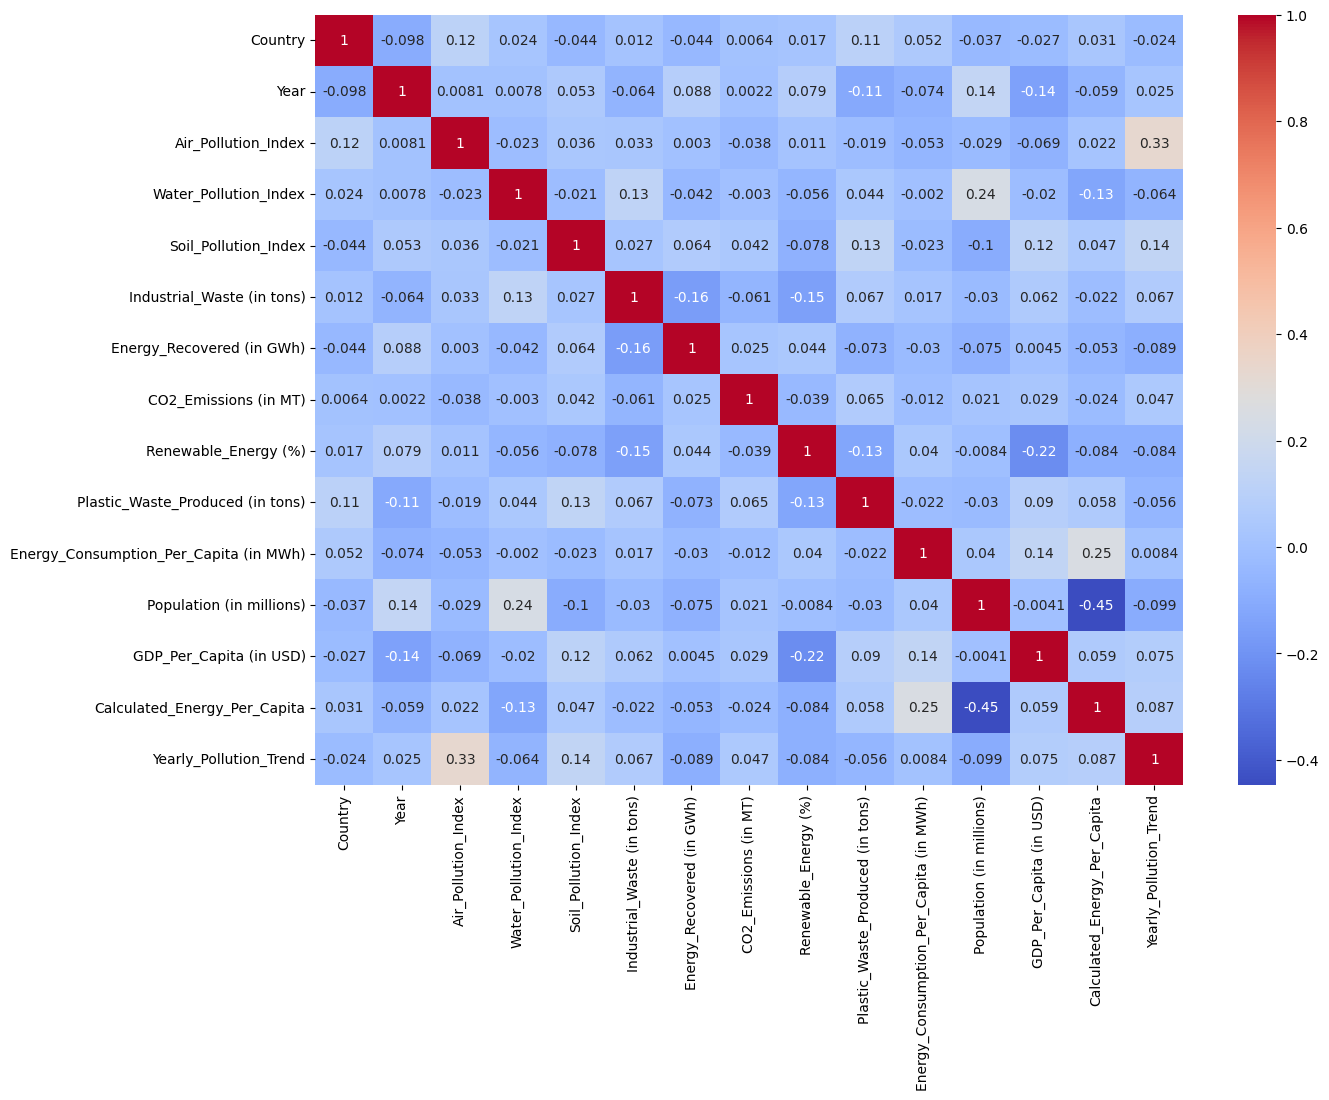

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

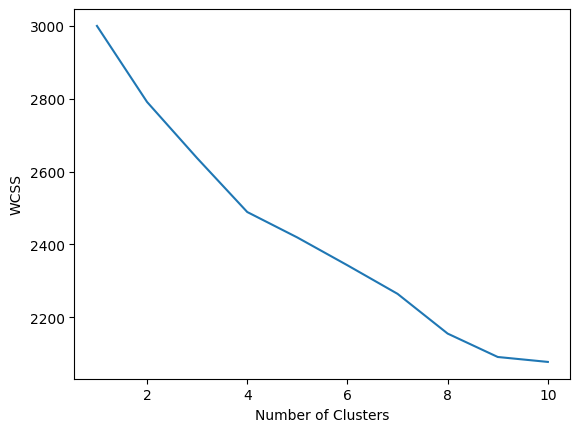

In [11]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(df)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['KMeans_Cluster'] = kmeans.fit_predict(df)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita,Yearly_Pollution_Trend,KMeans_Cluster
0,-0.232434,-0.753796,1.376167,0.193880,-0.619764,1.543328,-0.697051,-1.356325,1.079423,0.874923,0.561742,-1.093143,-0.737646,0.127192,-0.039399,1
1,1.173213,-1.449340,-1.403578,-1.153098,1.028744,0.124915,1.618760,-1.284276,0.700701,0.600289,-0.756197,0.580978,-0.023527,-0.336747,-1.929896,1
2,0.952326,1.158950,-1.330788,-0.668076,1.142400,0.123888,1.560644,1.718910,-1.493780,-0.395504,0.667825,0.355836,1.156054,-0.215940,-0.776072,0
3,-1.015580,1.506722,1.494394,-1.009403,0.431675,0.809131,-0.785350,-1.106232,-0.716061,-1.064327,-1.556310,-0.642506,-0.693157,-0.384327,2.871831,2
4,-0.854934,-0.232138,-0.021926,0.262567,1.138106,0.882681,-1.499375,-0.689181,0.502825,1.024815,0.612087,1.448956,0.312447,-0.281775,0.640361,0


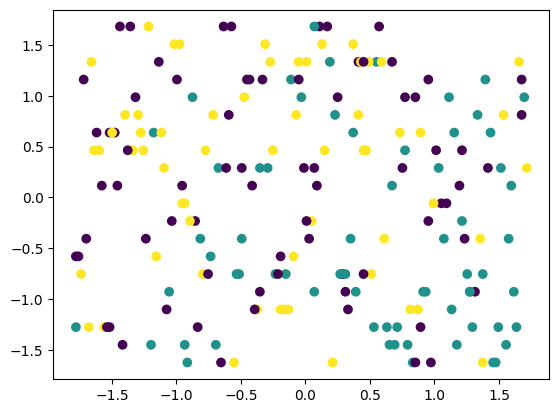

In [13]:
plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df['KMeans_Cluster']
)

plt.show()

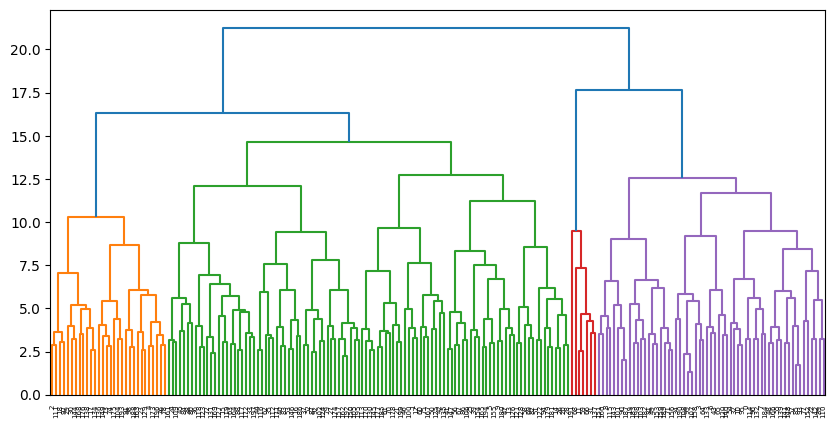

In [14]:
linked = linkage(df, method='ward')

plt.figure(figsize=(10,5))

dendrogram(linked)

plt.show()

In [16]:
hc = AgglomerativeClustering(n_clusters=3)

df['Hierarchical_Cluster'] = hc.fit_predict(df)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Calculated_Energy_Per_Capita,Yearly_Pollution_Trend,KMeans_Cluster,Hierarchical_Cluster
0,-0.232434,-0.753796,1.376167,0.193880,-0.619764,1.543328,-0.697051,-1.356325,1.079423,0.874923,0.561742,-1.093143,-0.737646,0.127192,-0.039399,1,1
1,1.173213,-1.449340,-1.403578,-1.153098,1.028744,0.124915,1.618760,-1.284276,0.700701,0.600289,-0.756197,0.580978,-0.023527,-0.336747,-1.929896,1,0
2,0.952326,1.158950,-1.330788,-0.668076,1.142400,0.123888,1.560644,1.718910,-1.493780,-0.395504,0.667825,0.355836,1.156054,-0.215940,-0.776072,0,0
3,-1.015580,1.506722,1.494394,-1.009403,0.431675,0.809131,-0.785350,-1.106232,-0.716061,-1.064327,-1.556310,-0.642506,-0.693157,-0.384327,2.871831,2,1
4,-0.854934,-0.232138,-0.021926,0.262567,1.138106,0.882681,-1.499375,-0.689181,0.502825,1.024815,0.612087,1.448956,0.312447,-0.281775,0.640361,0,0


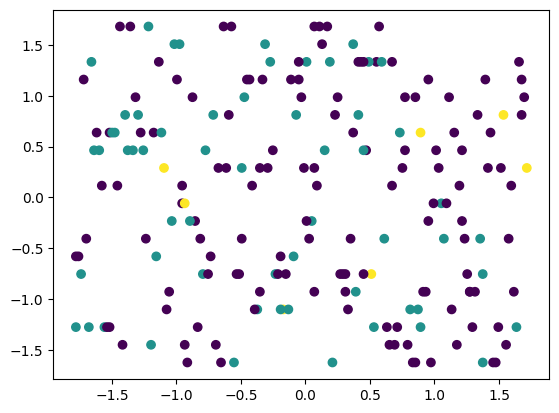

In [17]:
plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df['Hierarchical_Cluster']
)

plt.show()

In [18]:
target_col = 'Energy_Recovered (in GWh)'

X = df.drop(columns=[target_col])
y = df[target_col]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = Sequential()

model.add(Dense(
    64,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dense(
    1,
    activation='linear'
))

model.compile(
    optimizer=Adam(),
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 1.2456 - mae: 0.9305 - val_loss: 1.0648 - val_mae: 0.8502
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0878 - mae: 0.8879 - val_loss: 1.0523 - val_mae: 0.8533
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9955 - mae: 0.8477 - val_loss: 1.0476 - val_mae: 0.8579
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9183 - mae: 0.8061 - val_loss: 1.0436 - val_mae: 0.8604
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8576 - mae: 0.7755 - val_loss: 1.0524 - val_mae: 0.8637
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8041 - mae: 0.7467 - val_loss: 1.0514 - val_mae: 0.8643
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7663 - mae: 0.7281 - val_loss: 1.0469 - val_mae: 0.8650
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7272 - mae: 0.7088 - val_loss: 1.0388 - val_mae: 0.8655
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6944 - mae: 0.6922 - 

In [22]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [23]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 1.6383109182325235
MAE: 1.0829735840144212
R2 Score: -0.45947209416360657


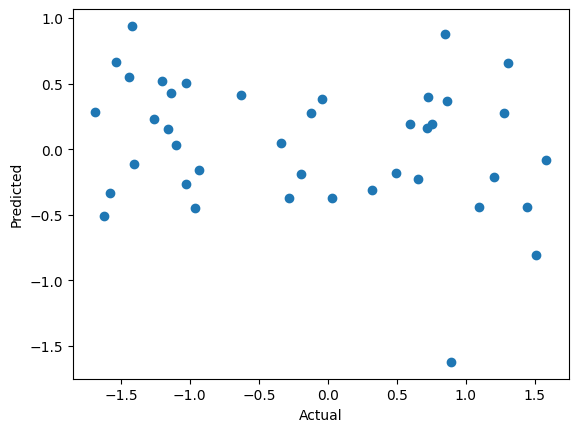

In [24]:
plt.scatter(y_test, y_pred)

plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.show()

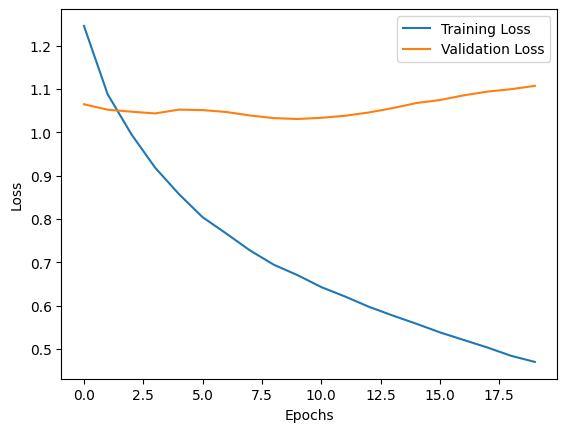

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

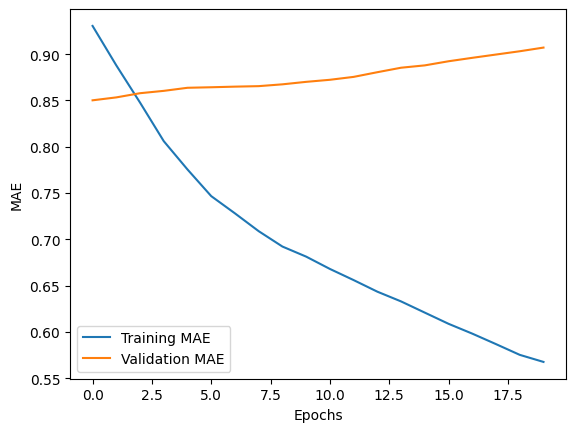

In [26]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

plt.xlabel('Epochs')
plt.ylabel('MAE')

plt.legend([
    'Training MAE',
    'Validation MAE'
])

plt.show()

In [27]:
print("Actionable Insights:")
print("1. Countries with high pollution require stronger environmental policies.")
print("2. Renewable energy initiatives can improve energy recovery.")
print("3. Clustering helps identify countries with similar pollution patterns.")
print("4. Neural Networks improve prediction of energy recovery.")

Actionable Insights:
1. Countries with high pollution require stronger environmental policies.
2. Renewable energy initiatives can improve energy recovery.
3. Clustering helps identify countries with similar pollution patterns.
4. Neural Networks improve prediction of energy recovery.
